<a href="https://colab.research.google.com/github/aspariz/belajar-html/blob/main/President_Obama's_Automatic_Dog_Door.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 # Load data di Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!wget -P /content/drive/MyDrive/data https://www.dropbox.com/s/6p1g7jmpr44rjdp/presidential_doggy_door.zip

--2025-07-27 15:17:17--  https://www.dropbox.com/s/6p1g7jmpr44rjdp/presidential_doggy_door.zip
Resolving www.dropbox.com (www.dropbox.com)... 162.125.8.18, 2620:100:601b:18::a27d:812
Connecting to www.dropbox.com (www.dropbox.com)|162.125.8.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/x0wvc1vcwr6qujajc4me3/presidential_doggy_door.zip?rlkey=7vhepdrg103bbfxz6fgwonqya [following]
--2025-07-27 15:17:18--  https://www.dropbox.com/scl/fi/x0wvc1vcwr6qujajc4me3/presidential_doggy_door.zip?rlkey=7vhepdrg103bbfxz6fgwonqya
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc1feca384b52f5558a61d3a4e9d.dl.dropboxusercontent.com/cd/0/inline/CuSvI0jfZd2JWYEMLKatZHcNS3-Vi1sC9_OAE8E6oxH2abehkiUNMpjlmDTW6NzyliQ9DHCs39FKhpQ0d_O6AWpfwNm-4VuFf9j62uO5g1omvoRNujA7WUSl6XtRSwpi0Cb3gcFQI-9tQIb_593xadXp/file# [following]
--2025-07-27 15:17:18--  https://uc1feca384b52f5558a61d3

In [ ]:
#Mengekstrak File zip ke direktori
import zipfile,os
local_zip = '/content/drive/MyDrive/woksop/presidential_doggy_door.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/content/drive/MyDrive/data/')
zip_ref.close()

#Mempersiapkan direktori untuk data training dan data validasi
base_dir = '/content/drive/MyDrive/data/presidential_doggy_door/'

#Mengecek direktori hasil ekstraksi
os.listdir(base_dir)

['train', 'valid']

In [ ]:
pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 83.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.9/319.9 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 105.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 111.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 116.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.31.1
    Uninstalling protobuf-6.31.1:
      Successfully uninstalled protobuf-6.31.1


In [ ]:
from tensorflow import keras

base_model = keras.applications.VGG16(
    weights = 'imagenet',
    input_shape = (224, 224, 3),
    include_top = False
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
base_model.trainable = False

In [ ]:
input = keras.Input(shape=(224, 224, 3))
x = base_model(input, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
output = keras.layers.Dense(1)(x)
model = keras.Model(input, output)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,715,201 (56.13 MB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model.compile(loss=keras.losses.BinaryCrossentropy(from_logits=True), metrics=[keras.metrics.BinaryAccuracy()])

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    samplewise_center=True,  # set each sample mean to 0
    rotation_range=10,  # randomly rotate images in the range (degrees, 0 to 180)
    zoom_range = 0.1, # Randomly zoom image
    rescale = 1./255, #rescalimage
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip = False
)

In [ ]:
# load training dataset
train_data = datagen.flow_from_directory('/content/drive/MyDrive/data/presidential_doggy_door/train/',
                                       target_size=(224, 224),
                                       color_mode='rgb',
                                       class_mode='binary',
                                       batch_size=8)

valid_data = datagen.flow_from_directory('/content/drive/MyDrive/data/presidential_doggy_door/valid/',
                                      target_size=(224, 224),
                                      color_mode='rgb',
                                      class_mode='binary',
                                      batch_size=8)

Found 139 images belonging to 2 classes.
Found 34 images belonging to 2 classes.


In [ ]:
history = model.fit(train_data, steps_per_epoch=5, validation_data=valid_data, epochs=20)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 25s 5s/step - binary_accuracy: 0.0252 - loss: 1.5814 - val_binary_accuracy: 0.2941 - val_loss: 0.9411
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - binary_accuracy: 0.1437 - loss: 0.9950 - val_binary_accuracy: 0.2941 - val_loss: 0.8021
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - binary_accuracy: 0.2316 - loss: 0.7724 - val_binary_accuracy: 0.2941 - val_loss: 0.7134
Epoch 4/20
3/5 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - binary_accuracy: 0.1389 - loss: 0.7059

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


5/5 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - binary_accuracy: 0.1500 - loss: 0.6963 - val_binary_accuracy: 0.2941 - val_loss: 0.6712
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - binary_accuracy: 0.2837 - loss: 0.6294 - val_binary_accuracy: 0.3529 - val_loss: 0.6457
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - binary_accuracy: 0.5403 - loss: 0.5100 - val_binary_accuracy: 0.7059 - val_loss: 0.6069
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - binary_accuracy: 0.7896 - loss: 0.4923 - val_binary_accuracy: 0.7059 - val_loss: 0.5973
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - binary_accuracy: 0.8500 - loss: 0.4677 - val_binary_accuracy: 0.7059 - val_loss: 0.6162
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 24s 5s/step - binary_accuracy: 0.8597 - loss: 0.4573 - val_binary_accuracy: 0.7059 - val_loss: 0.6196
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - binary_accuracy: 0.8885 - loss: 0.3821 - val_binary_accuracy: 0.7059 - val_loss: 0.6319
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/

The error `PIL.UnidentifiedImageError: cannot identify image file` indicates that the `ImageDataGenerator` encountered a file in your dataset that it cannot recognize as an image. This could be due to corrupted files or files with incorrect extensions.

To diagnose this, we can iterate through the directories and try to open each file to see which one is causing the issue.

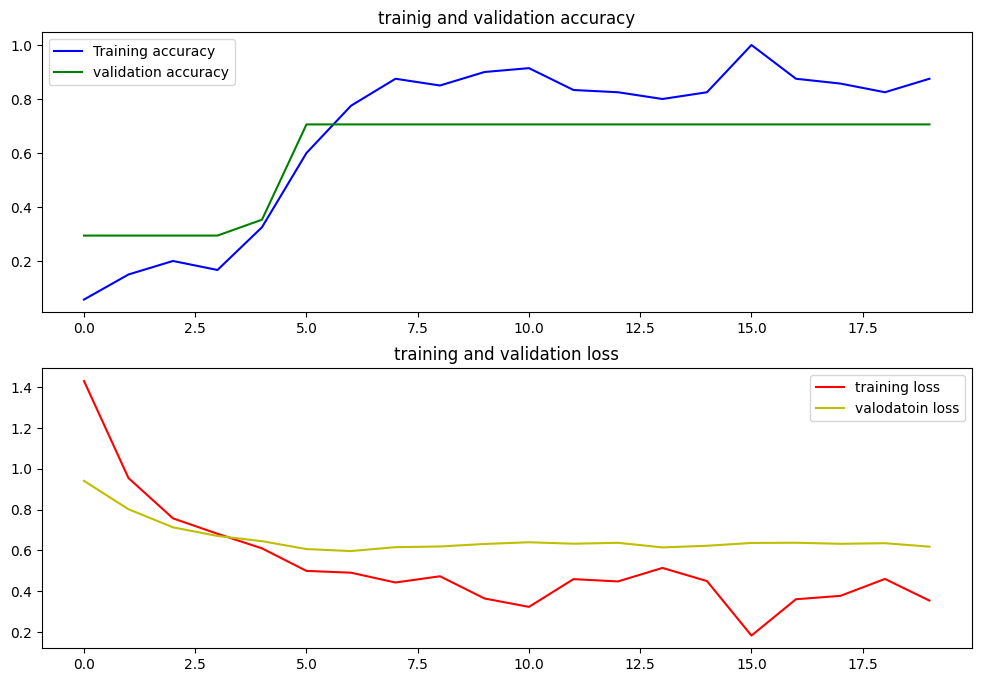

In [ ]:
import matplotlib.pyplot as plt

accur = history.history['binary_accuracy']
val_accur = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(accur))

plt.figure(figsize=(12,8))
plt.subplot(2, 1, 1)
plt.plot(epochs, accur, 'b', label='Training accuracy')
plt.plot(epochs, val_accur, 'g', label='validation accuracy')
plt.title('trainig and validation accuracy')
plt.legend(loc=0)

plt.subplot(2, 1, 2)
plt.plot(epochs, loss, 'r', label='training loss')
plt.plot(epochs, val_loss, 'y', label='valodatoin loss')
plt.title('training and validation loss')
plt.legend(loc=0)

plt.show()

In [ ]:
base_model.trainable = True
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate= .00001),
              loss=keras.losses.BinaryCrossentropy(from_logits=True),
              metrics=[keras.metrics.BinaryAccuracy()])

In [ ]:
history2=model.fit(train_data, steps_per_epoch=10, validation_data=valid_data, epochs=20)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 138s 14s/step - binary_accuracy: 0.7666 - loss: 0.4476 - val_binary_accuracy: 0.7059 - val_loss: 0.9068
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 102s 11s/step - binary_accuracy: 0.8202 - loss: 0.4324 - val_binary_accuracy: 0.7353 - val_loss: 0.5012
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 133s 13s/step - binary_accuracy: 0.8924 - loss: 0.2331 - val_binary_accuracy: 0.7941 - val_loss: 0.4074
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 102s 10s/step - binary_accuracy: 0.9300 - loss: 0.2260 - val_binary_accuracy: 0.8529 - val_loss: 0.3271
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 127s 13s/step - binary_accuracy: 0.9620 - loss: 0.1443 - val_binary_accuracy: 0.9118 - val_loss: 0.3194
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 110s 11s/step - binary_accuracy: 0.9731 - loss: 0.0946 - val_binary_accuracy: 0.8824 - val_loss: 0.2816
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 126s 13s/step - binary_accuracy: 0.9891 - loss: 0.1129 - val_binary_accuracy: 0.8529 - val_loss: 0.2808
Epoch 

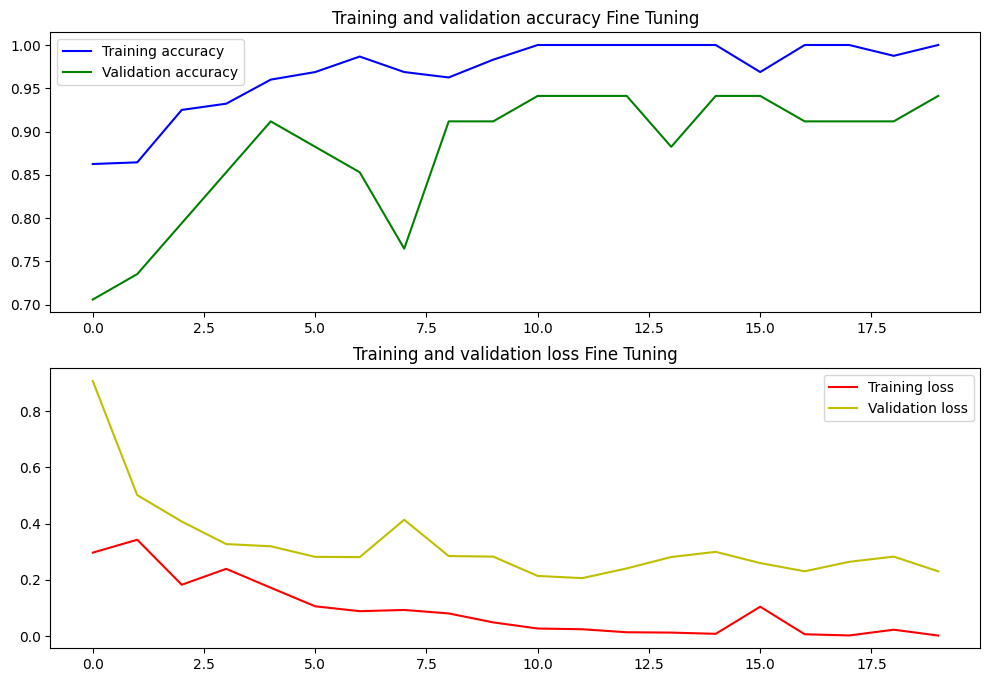

In [ ]:
#Plot Akurasi dan Loss
import matplotlib.pyplot as plt

accur = history2.history['binary_accuracy']
val_accur = history2.history['val_binary_accuracy']
loss = history2.history['loss']
val_loss = history2.history['val_loss']

epochs = range(len(accur))

plt.figure(figsize=(12,8))
plt.subplot(2, 1, 1)
plt.plot(epochs, accur, 'b', label='Training accuracy')
plt.plot(epochs, val_accur, 'g', label='Validation accuracy')
plt.title('Training and validation accuracy Fine Tuning')
plt.legend(loc=0)


plt.subplot(2, 1, 2)
plt.plot(epochs, loss, 'r', label='Training loss')
plt.plot(epochs, val_loss, 'y', label='Validation loss')
plt.title('Training and validation loss Fine Tuning')
plt.legend(loc=0)


plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.preprocessing import image as image_utils
from tensorflow.keras.applications.imagenet_utils import preprocess_input

def show_image(image_path):
    image = mpimg.imread(image_path)
    plt.imshow(image)

def prediksi(image_path):
    show_image(image_path)
    image = image_utils.load_img(image_path, target_size=(224, 224))
    image = image_utils.img_to_array(image)
    image = image.reshape(1,224,224,3)
    image = preprocess_input(image)
    preds = model.predict(image)
    return preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step


array([[-80.983826]], dtype=float32)

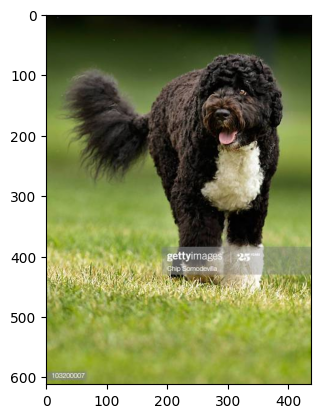

In [ ]:
prediksi('/content/drive/MyDrive/data/presidential_doggy_door/valid/bo/bo_20.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step


array([[259.09235]], dtype=float32)

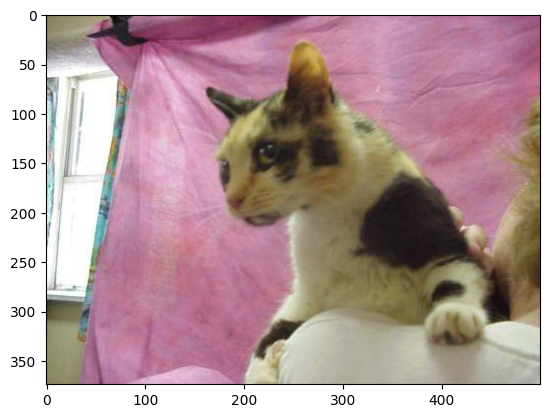

In [ ]:
prediksi('/content/drive/MyDrive/data/presidential_doggy_door/valid/not_bo/121.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step


array([[373.75253]], dtype=float32)

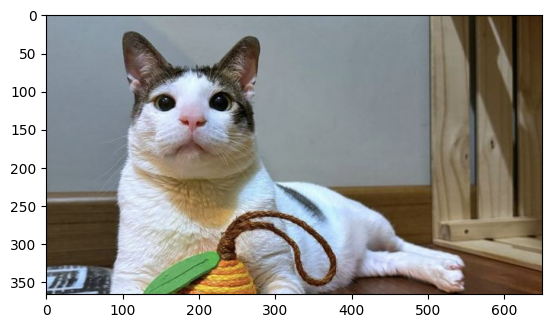

In [ ]:
prediksi('/content/drive/MyDrive/data/presidential_doggy_door/valid/not_bo/bobby.jpg')

# **`Gate funcion`**

In [ ]:
def input_image(image_path):
    preds = prediksi(image_path)
    if preds[0] < 0:
        print('\nitu bo \n silahkan masuk')
    else:
        print('itu bukan bo \n Tidak boleh Masuk')

In [ ]:
input_image('/content/drive/MyDrive/data/presidential_doggy_door/valid/not_bo/bobby.jpg')

NameError: name 'input_image' is not defined

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 820ms/step

itu bo 
 silahkan masuk


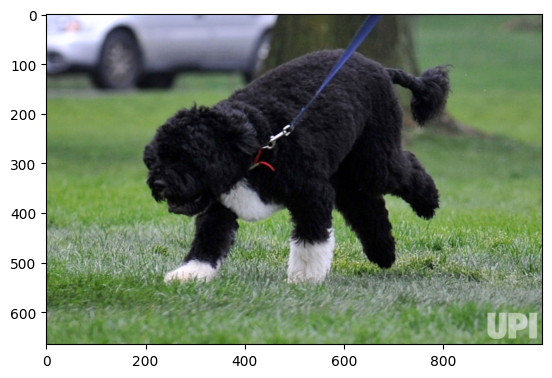

In [ ]:
input_image('/content/drive/MyDrive/data/presidential_doggy_door/valid/not_bo/bo_28.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 721ms/step
itu bo


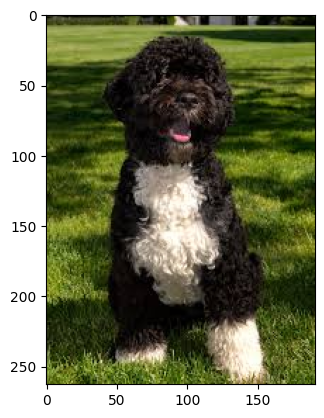

In [ ]:
presiden_dog('/content/drive/MyDrive/data/presidential_doggy_door/valid/not_bo/boo.jpeg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 679ms/step
itu bukan bo 
 Tidak boleh Masuk


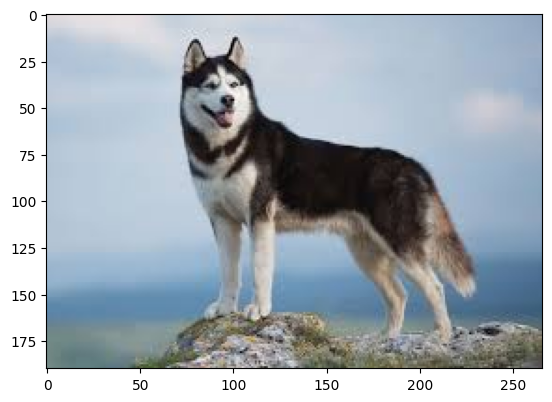

In [ ]:
input_image('/content/drive/MyDrive/husky.jpeg')